In [1]:
import os
import pandas as pd
from PIL import Image
import torch
import torchvision.transforms as T
import torch.nn.functional as F
import numpy as np 



import matplotlib.pyplot as plt

In [2]:
def track_new_minima(df):
    current_min = float('inf')
    new_minima = []

    for idx, value in enumerate(df['Loss']):
        if value < current_min:
            current_min = value
            new_minima.append((idx, value))

    # print("new_minima ", new_minima)
    return pd.DataFrame(new_minima, columns=['index', 'new_min_loss'])

results_3d_usvol3_ds4_6 min loss:  0.0041311110031797
results_3d_usvol3_ds45_1 min loss:  0.0033472539242236


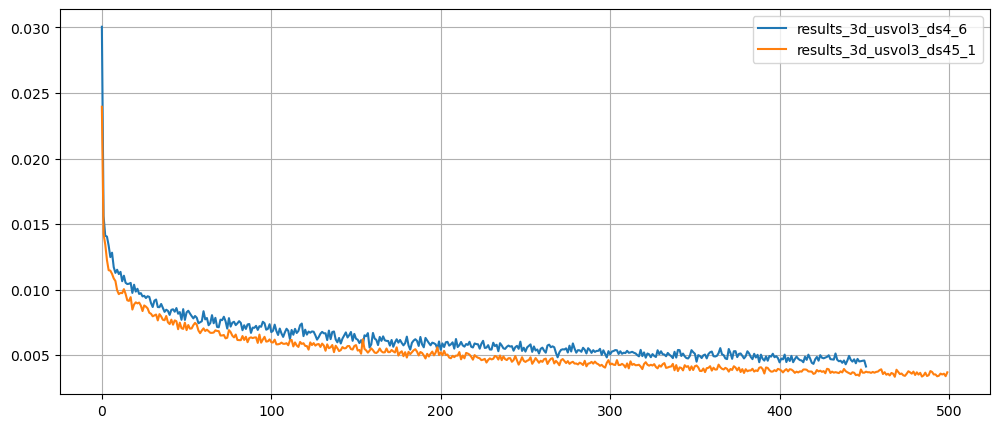

In [3]:
def plot_multiple_loss(results_list, oneplot = True):

    
    if oneplot:
        plt.figure(figsize=(12,5))

    
    for res in results_list:

        df = pd.read_csv(res)
        name = res.split("/")[0]

        print(name, "min loss: ", df['Loss'].min())



        x = df["Epoch"].values.tolist()
        y = df["Loss"].values.tolist()

        if not oneplot:
            plt.figure(figsize=(12,5))
        plt.plot(x,y, label = name )

        # plt.title(name)

        if not oneplot:
            plt.grid()
            plt.legend()
            plt.show()

    if oneplot:
        plt.grid()
        plt.legend()
        plt.show()

results_list =  ["results_3d_usvol3_ds4_6/training_log.csv", "results_3d_usvol3_ds45_1/training_log.csv"]

plot_multiple_loss(results_list, oneplot = True)

In [4]:
def cont_results_combine(results_list):
    res = results_list[0]
    res_cont = results_list[1]

    df = pd.read_csv(res)
    df_cont = pd.read_csv(res_cont)

    x = df["Epoch"].values.tolist()
    y = df["Loss"].values.tolist()
    # y = df["Loss"].values.tolist()[50:]

    x.extend([i for i in range(len(x), len(x)+df_cont.shape[0])])
    y.extend(df_cont["Loss"].values.tolist())

    df_con = pd.concat([df, df_cont], ignore_index=True)


    df_con["Epoch"] = np.arange(0, len(y))

    return df_con


# res = "results_3d_usvol3_ds4_2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
# res_cont = "results_3d_usvol3_ds4_2_cont_v2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"


res = "results_cropped_test/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
res_cont = "results_cropped_test_cont/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"



df_comb = cont_results_combine([res, res_cont])

/tmp/ipykernel_929080/3880527925.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_con = pd.concat([df, df_cont], ignore_index=True)


In [4]:
def plot_loss_learning(result):

    if isinstance(result, str):
        df = pd.read_csv(result)
        name = result.split("/")[0]

    else:

        df = result
        name = ""

    print(name, "min loss: ", df['Loss'].min())

    fig, ax1 = plt.subplots()

    # df['Learning Rate'].plot(legend=name, ax=ax1)

    ax1.plot(df["Epoch"].values[1:], df["Learning Rate"].values[1:])
    ax1.tick_params(axis='y')


    result = track_new_minima(df)
    # print(result)
    print(f"Total new minima found: {len(result)}")

 
    # plot new_min_loss during training on learning rate plot.

    nml_x = result["index"]
    nml_y = df.loc[nml_x]["Learning Rate"]
    nml_y_loss = df.loc[nml_x]["Loss"]
    print(len(nml_y))
    print(len(nml_x[nml_x < 200]), len(nml_x[nml_x.between(200,400)]), len(nml_x[nml_x.between(400,600)]),  len(nml_x[nml_x.between(600,800)]),len(nml_x[nml_x > 800]))

    print("last lr ", nml_y[-1:])

    ax1.scatter(nml_x[1:], nml_y[1:], c = "red", s = 10)

    # lr_lin = np.linspace(0.0001, 0, 6)
    # for i in range(len(lr_lin)-1):
    #     lr_h = lr_lin[i]
    #     lr_l = lr_lin[i+1]
    #     print(f"in range {lr_h} to {lr_l} ",len(nml_y[nml_y.between(lr_l, lr_h)]))



    ax2 = ax1.twinx()
    # result.plot(x = "index", y = "new_min_loss", kind = "scatter")
    # ax2.scatter(nml_x[1:], nml_y[1:], c = "red", s = 10)
    ax2.scatter(nml_x[1:], nml_y_loss[1:], c = "green", s = 10)

    ax2.scatter(df['Loss'].argmin(), df['Loss'].min(), c = "yellow", s = 30)
    print("m ", nml_y_loss.min(), nml_y_loss.argmin())


    ax2.tick_params(axis='y')
    # ax2.grid()
    fig.tight_layout()
    plt.legend()
    plt.title(name)
    plt.show()

In [7]:
results_list = ["results_3d_usvol3_3_cont/training_log.csv", "results_3d_usvol3_2_v3/training_log.csv", "results_3d_usvol3_2_v4/training_log.csv", 
                "results_3d_usvol3_ds4_1/training_log.csv", "results_3d_usvol3_ds4_2/training_log.csv", "results_3d_usvol3_ds4_2_cont_v2/training_log.csv",
                "results_3d_usvol3_ds45_1/training_log.csv", "results_cropped_test_cont/training_log.csv", "results_cropped_test_multigpu/training_log.csv",
                "results_dataset_Vol3_123/training_log.csv",
                "results_dataset_Vol3_345_f/training_log.csv",
                "results_dataset_cropped3_f/training_log.csv",
                "results_dataset_cropped3_f_2/training_log.csv"]

for res in results_list:
    # print(res.split("/")[0])

    df = pd.read_csv(res)
    name = res.split("/")[0]

    print(name, df['Loss'].min())


    # print(name, df['Learning Rate'][-2:])


results_3d_usvol3_3_cont 0.005091797787038
results_3d_usvol3_2_v3 0.0020921836977451
results_3d_usvol3_2_v4 0.0017691731155125
results_3d_usvol3_ds4_1 0.0028424866717268
results_3d_usvol3_ds4_2 0.0029227843459801
results_3d_usvol3_ds4_2_cont_v2 0.0024617413976121
results_3d_usvol3_ds45_1 0.0033472539242236
results_cropped_test_cont 0.0028752567336188
results_cropped_test_multigpu 0.0039775939943559
results_dataset_Vol3_123 0.0020291517999298
results_dataset_Vol3_345_f 0.003391469283749
results_dataset_cropped3_f 0.0028082214201133
results_dataset_cropped3_f_2 0.0258839328901148


In [10]:
results_list = ["results_3d_usvol3_3_cont/training_log.csv", "results_3d_usvol3_2_v3/training_log.csv", "results_3d_usvol3_2_v4/training_log.csv", 
                "results_3d_usvol3_ds4_1/training_log.csv", "results_3d_usvol3_ds4_2/training_log.csv", "results_3d_usvol3_ds4_2_cont_v2/training_log.csv",
                "results_3d_usvol3_ds45_1/training_log.csv", "results_cropped_test_cont/training_log.csv", "results_cropped_test_multigpu/training_log.csv",
                "results_dataset_Vol3_123/training_log.csv",
                "results_dataset_Vol3_345_f/training_log.csv",
                "results_dataset_cropped3_f/training_log.csv",
                "results_dataset_cropped3_f_3/training_log.csv",

                "results_dataset_Vol3_345_f_2_cont/training_log.csv",
                "results_dataset_Vol3_f_1/training_log.csv",
                "results_dataset_Vol3_f_2/training_log.csv",
                "results_dataset_Vol3_f_2_cont/training_log.csv"]


for res in results_list:
    # print(res.split("/")[0])

    df = pd.read_csv(res)
    name = res.split("/")[0]

    print(name, df['Loss'].min())

results_3d_usvol3_3_cont 0.005091797787038
results_3d_usvol3_2_v3 0.0020921836977451
results_3d_usvol3_2_v4 0.0017691731155125
results_3d_usvol3_ds4_1 0.0028424866717268
results_3d_usvol3_ds4_2 0.0029227843459801
results_3d_usvol3_ds4_2_cont_v2 0.0024617413976121
results_3d_usvol3_ds45_1 0.0033472539242236
results_cropped_test_cont 0.0028752567336188
results_cropped_test_multigpu 0.0039775939943559
results_dataset_Vol3_123 0.0020291517999298
results_dataset_Vol3_345_f 0.003391469283749
results_dataset_cropped3_f 0.0028082214201133
results_dataset_cropped3_f_3 0.0031393241190112
results_dataset_Vol3_345_f_2_cont 0.0015712722250927
results_dataset_Vol3_f_1 0.003036146579197
results_dataset_Vol3_f_2 0.0031424749114022
results_dataset_Vol3_f_2_cont 0.0021747248357388


In [9]:
# df = pd.read_csv(res, index_col=False)
# df.head(10)

# df.to_csv(res, index=False)

/tmp/ipykernel_929080/1396559828.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(res, index_col=False)


results_dataset_Vol3_f_1 min loss:  0.003036146579197
Total new minima found: 38
38
25 4 3 4 2
in range 0.0001 to 8e-05  29
in range 8e-05 to 6e-05  3
in range 6e-05 to 3.9999999999999996e-05  4
in range 3.9999999999999996e-05 to 1.9999999999999998e-05  2
in range 1.9999999999999998e-05 to 0.0  0


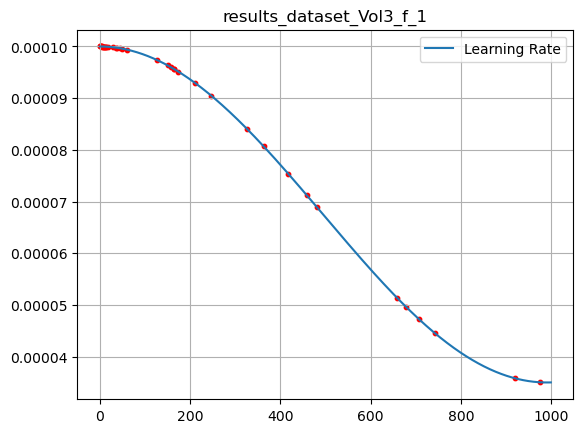

In [7]:
results_list = ["results_3d_usvol3_ds4_1/training_log.csv", "results_3d_usvol3_ds4_2/training_log.csv"] # "results_3d_usvol3_ds4_2/training_log.csv"

results_list =  ["results_3d_usvol3_ds4_3/training_log.csv"]
# results_list =  ["results_3d_usvol3_ds4_2_cont_v2_2/training_log.csv"]

results_list = ["results_3d_usvol3_ds4_2/training_log.csv", "results_3d_usvol3_ds4_6/training_log.csv"] # "results_3d_usvol3_ds4_2/training_log.csv"

results_list =  ["results_3d_usvol3_ds4_6/training_log.csv", "results_3d_usvol3_ds45_1/training_log.csv"]



results_list =  ["results_cropped_test/training_log.csv", "results_cropped_test_multigpu/training_log.csv"]

results_list =  ["results_dataset_Vol3_123/training_log.csv"]

results_list =  ["results_dataset_Vol3_345_f/training_log.csv"]
results_list =  ["results_dataset_Vol3_345_f_2_cont/training_log.csv"]

results_list =  ["results_dataset_Vol3_f_1/training_log.csv"]

# results_list =  ["results_dataset_cropped3_f/training_log.csv"]
# results_list =  ["results_dataset_cropped3_f_3/training_log.csv"]

for res in results_list:
    # print(res.split("/")[0])

    df = pd.read_csv(res)
    name = res.split("/")[0]

    print(name, "min loss: ", df['Loss'].min())

    df['Learning Rate'].plot(legend=name)


    result = track_new_minima(df)
    # print(result)
    print(f"Total new minima found: {len(result)}")

 
    # plot new_min_loss during training on learning rate plot.

    nml_x = result["index"]
    nml_y = df.loc[nml_x]["Learning Rate"]
    print(len(nml_y))
    print(len(nml_x[nml_x < 200]), len(nml_x[nml_x.between(200,400)]), len(nml_x[nml_x.between(400,600)]),  len(nml_x[nml_x.between(600,800)]),len(nml_x[nml_x > 800]))


    lr_lin = np.linspace(0.0001, 0, 6)
    for i in range(len(lr_lin)-1):
        lr_h = lr_lin[i]
        lr_l = lr_lin[i+1]
        print(f"in range {lr_h} to {lr_l} ",len(nml_y[nml_y.between(lr_l, lr_h)]))


    # result.plot(x = "index", y = "new_min_loss", kind = "scatter")
    plt.scatter(nml_x, nml_y, c = "red", s = 10)
    plt.grid()
    plt.legend()
    plt.title(name)
    plt.show()
# plt.legend()



In [17]:
# results_list = ["results_3d_usvol3_ds4_2/training_log.csv", "results_3d_usvol3_ds4_6/training_log.csv"] # "results_3d_usvol3_ds4_2/training_log.csv"

# results_list =  ["results_3d_usvol3_ds4_2/training_log.csv"]
results_list =  ["results_cropped_test/training_log.csv"]


# plot_loss_learning(results_list[0])

results_dataset_cropped3_f_2 min loss:  0.0022959247689155
Total new minima found: 46
46
28 3 4 1 10
last lr  1360    0.000021
Name: Learning Rate, dtype: float64
m  0.0022959247689155 45


/tmp/ipykernel_2359340/232751173.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


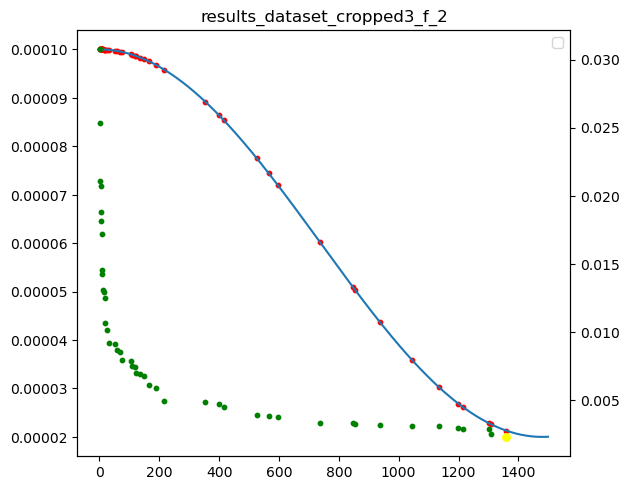

In [8]:

results_list =  ["results_dataset_Vol3_123/training_log.csv"]
results_list =  ["results_dataset_Vol3_345_f/training_log.csv"]



results_list =  ["results_dataset_cropped3_f_2/training_log.csv"]


plot_loss_learning(results_list[0])

In [55]:
len(nml_x[nml_x.between(200,400)])

9

 min loss:  0.0015712722250927
Total new minima found: 55
55
34 6 4 4 7
last lr  1424    0.000004
Name: Learning Rate, dtype: float64
m  0.0015712722250927 54


/tmp/ipykernel_929080/232751173.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


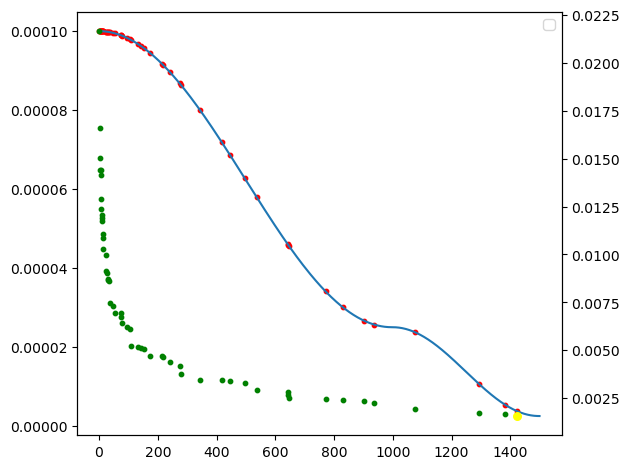

In [13]:

res = "results_dataset_Vol3_345_f_2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
res_cont = "results_dataset_Vol3_345_f_2_cont/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"

    # print(res.split("/")[0])

df_comb = cont_results_combine([res, res_cont])


plot_loss_learning(df_comb)



 min loss:  0.0021747248357388
Total new minima found: 52
52
33 6 2 2 9
last lr  1756    0.000005
Name: Learning Rate, dtype: float64
m  0.0021747248357388 51


/tmp/ipykernel_929080/232751173.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


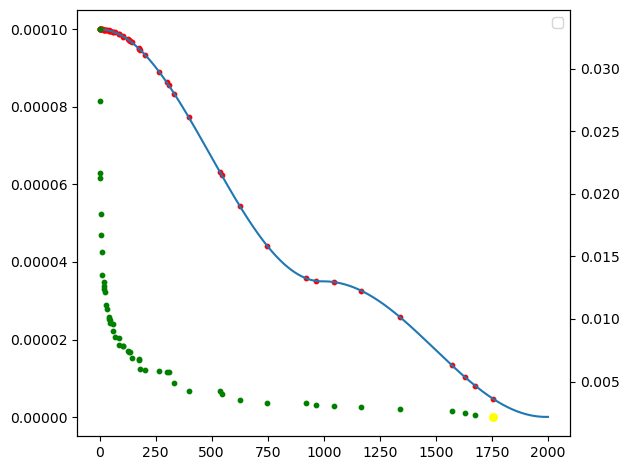

In [11]:
# Add to previus training

res = "results_dataset_Vol3_f_2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
res_cont = "results_dataset_Vol3_f_2_cont/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"

    # print(res.split("/")[0])

df_comb = cont_results_combine([res, res_cont])


plot_loss_learning(df_comb)

 min loss:  0.0024617413976121
Total new minima found: 86
86
46 9 6 7 18
last lr  1383    0.000006
Name: Learning Rate, dtype: float64
m  0.0024617413976121 85


/tmp/ipykernel_3552009/232751173.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


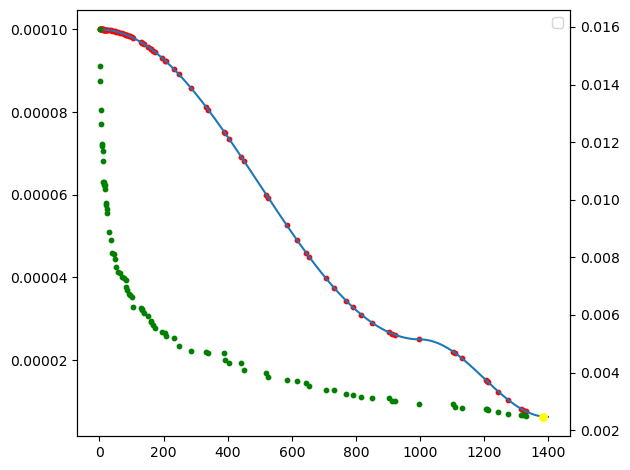

In [30]:
# Add to previus training

res = "results_3d_usvol3_ds4_2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
res_cont = "results_3d_usvol3_ds4_2_cont_v2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"

    # print(res.split("/")[0])

df_comb = cont_results_combine([res, res_cont])


plot_loss_learning(df_comb)

In [32]:
df_comb["Loss"][-10:]

1390    0.002738
1391    0.002570
1392    0.002642
1393    0.002674
1394    0.002592
1395    0.002700
1396    0.002866
1397    0.002820
1398    0.002891
1399    0.002917
Name: Loss, dtype: float64

 min loss:  0.0028752567336188
Total new minima found: 74
74
34 11 8 9 12
last lr  1460    1.605105e-07
Name: Learning Rate, dtype: float64
m  0.0028752567336188 73


/tmp/ipykernel_3552009/232751173.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


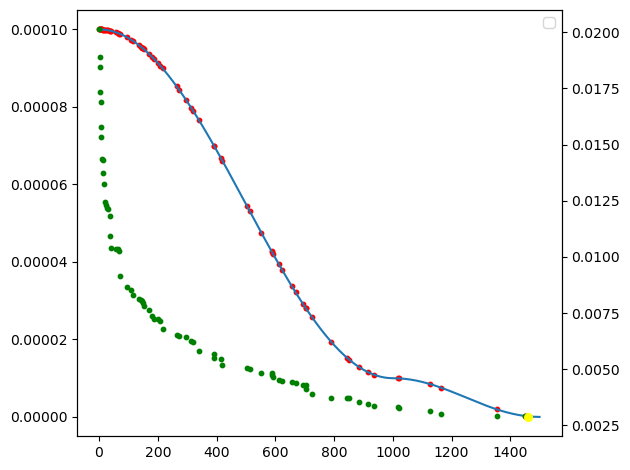

In [33]:

res = "results_cropped_test/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
res_cont = "results_cropped_test_cont/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"

    # print(res.split("/")[0])

df_comb = cont_results_combine([res, res_cont])


plot_loss_learning(df_comb)

 min loss:  0.0015712722250927
Total new minima found: 55
55
34 6 4 4 7
last lr  1424    0.000004
Name: Learning Rate, dtype: float64
m  0.0015712722250927 54


/tmp/ipykernel_1635738/232751173.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


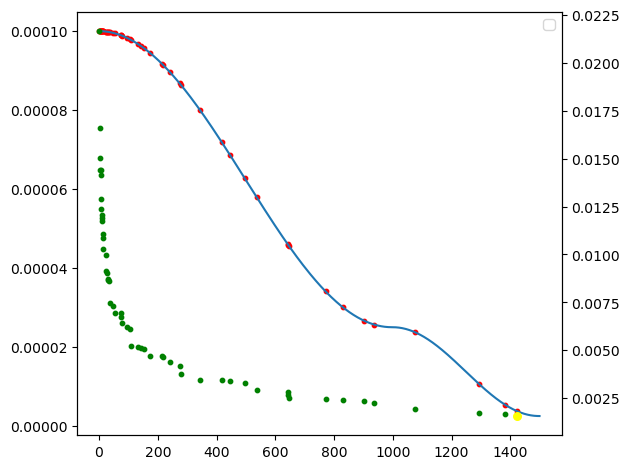

In [18]:
# results_dataset_Vol3_345_f_2

res = "results_dataset_Vol3_345_f_2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
res_cont = "results_dataset_Vol3_345_f_2_cont/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"

    # print(res.split("/")[0])

df_comb = cont_results_combine([res, res_cont])


plot_loss_learning(df_comb)

Total new minima found: 74
74
34 11 8 9 12
last lr  1460    1.605105e-07
Name: Learning Rate, dtype: float64
m  0.0028752567336188 73
Last 10 min loss  883     0.003555
915     0.003453
935     0.003369
1017    0.003310
1020    0.003273
1127    0.003133
1164    0.003010
1353    0.002916
1450    0.002908
1460    0.002875
Name: Loss, dtype: float64


/tmp/ipykernel_3552009/370331271.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


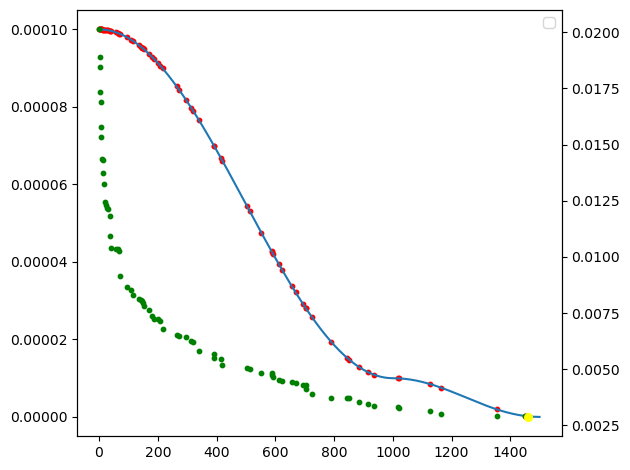

In [17]:
name= ""
fig, ax1 = plt.subplots()

# df['Learning Rate'].plot(legend=name, ax=ax1)

ax1.plot(df_comb.index.values[1:], df_comb["Learning Rate"].values[1:])
ax1.tick_params(axis='y')


result = track_new_minima(df_comb)
# print(result)
print(f"Total new minima found: {len(result)}")


# plot new_min_loss during training on learning rate plot.

nml_x = result["index"]
nml_y = df_comb.loc[nml_x]["Learning Rate"]
nml_y_loss = df_comb.loc[nml_x]["Loss"]
print(len(nml_y))
print(len(nml_x[nml_x < 200]), len(nml_x[nml_x.between(200,400)]), len(nml_x[nml_x.between(400,600)]),  len(nml_x[nml_x.between(600,800)]),len(nml_x[nml_x > 800]))

print("last lr ", nml_y[-1:])

ax1.scatter(nml_x[1:], nml_y[1:], c = "red", s = 10)

# lr_lin = np.linspace(0.0001, 0, 6)
# for i in range(len(lr_lin)-1):
#     lr_h = lr_lin[i]
#     lr_l = lr_lin[i+1]
#     print(f"in range {lr_h} to {lr_l} ",len(nml_y[nml_y.between(lr_l, lr_h)]))



ax2 = ax1.twinx()
# result.plot(x = "index", y = "new_min_loss", kind = "scatter")
# ax2.scatter(nml_x[1:], nml_y[1:], c = "red", s = 10)
ax2.scatter(nml_x[1:], nml_y_loss[1:], c = "green", s = 10)

ax2.scatter(df_comb['Loss'].argmin(), df_comb['Loss'].min(), c = "yellow", s = 30)
print("m ", nml_y_loss.min(), nml_y_loss.argmin())


print("Last 10 min loss ", nml_y_loss[-10:])

ax2.tick_params(axis='y')
# ax2.grid()
fig.tight_layout()
plt.legend()
plt.title(name)
plt.show()

In [14]:
# Add to previus training

res = "results_3d_usvol3_ds4_2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"
res_cont = "results_3d_usvol3_ds4_2_cont_v2/training_log.csv" # "results_3d_usvol3_ds4_2/training_log.csv"

res2 = "results_3d_usvol3_ds45_1/training_log.csv"

df2 = pd.read_csv(res2)


print(y[-5:])


df_con = cont_results_combine([res, res_cont])
# df_con["index"] = [i for i in range(df_con.shape[0])]


result = track_new_minima(df_con)
# result["index"]= [i for i in range(df_con.shape[0])]
# print(result)
print(f"Total new minima found: {len(result)}")


# plot new_min_loss during training on learning rate plot.

lr_lin = np.linspace(0.0001, 0, 6)

# result.plot(x = "index", y = "new_min_loss", kind = "scatter")
plt.figure(figsize = (12,6))


plt.plot(x, y)
plt.plot(df2["Epoch"].values.tolist(), df2["Loss"].values.tolist())

plt.grid()
    # plt.legend()
    # plt.title(name)
plt.show() 

NameError: name 'y' is not defined

results_dataset_liver_test4 min loss:  0.0035944561929103
Total new minima found: 23
23
14 1 1 1 6
last lr  1930    0.00001
Name: Learning Rate, dtype: float64
m  0.0035944561929103 22


/tmp/ipykernel_1778500/232751173.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


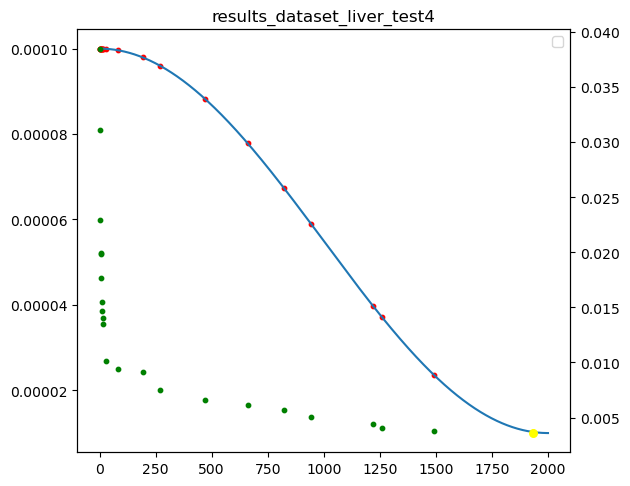

In [5]:
results_list =  ["results_dataset_liver_test4/training_log.csv"]



plot_loss_learning(results_list[0])


 